In [26]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


### Libraries

In [27]:
import importlib.util
import subprocess
import sys
import itertools
from termcolor import colored

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.1",
    "tqdm": "tqdm>=4.65",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print("missing packages: " + ", ".join(missing))

print("Environment ready")

Environment ready


In [28]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from models.DLinearZeroAware import DLinearZeroAware

print(DLinearZeroAware)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


<class 'models.DLinearZeroAware.DLinearZeroAware'>


device(type='cpu')

# Zero-aware global DLinear




Inputs
- Past sales + past numerical covariates

Outputs:
- probability of non-zero sales
- point forecast

Final output
- P(sales > 0) × forecast sales


Excluding future numerical covariates

In [29]:
FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
COMBINED_SPLIT_PATH = PROJECT_ROOT / "data/m5/processed/splits/combined_exclusive_series.csv"


### Prepare the grid of hyperparameters and scenarios

In [30]:
PRED_LEN = 28
BATCH_SIZE = 64
RANDOM_SEED = 42

# 0 means use all available series.
MAX_TRAIN_SERIES_PER_GROUP = 0
MAX_EVAL_SERIES_PER_GROUP = 0
EARLY_STOPPING_MIN_DELTA = 1e-5

# The two losses have same weight
OCCURRENCE_LOSS_WEIGHT = 1.0
MAGNITUDE_LOSS_WEIGHT = 1.0

# A zero probability threshold
ZERO_PROBABILITY_THRESHOLD = 0.5

GRID = {
    "seq_len": [28, 56, 112],
    "learning_rate": [1e-3, 3e-4],
    "epochs": [50],
    "samples_per_epoch": [10_000, 20_000, 40_000],
}

TRAIN_GROUPS = ["normal", "intermittent"]
EVAL_GROUPS = ["normal", "intermittent", "cold_start_item", "cold_start_store", "all_combined"]

MODEL_NAME = "global_dlinear_zero_aware"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [31]:
TARGET_COLUMN = "log_sales"

# v1 covariates. Past categorical values
COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
    "sell_price",
    #"price_change_pct",
]

MODEL_COLUMNS = [TARGET_COLUMN] + COVARIATE_COLUMNS
N_COVARIATES = len(COVARIATE_COLUMNS)
N_CHANNELS = len(MODEL_COLUMNS)

MODEL_COLUMNS


['log_sales',
 'day_of_week',
 'is_weekend',
 'event_flag',
 'snap_flag',
 'sell_price']

### Read data and prepare series

In [32]:
def sample_ids(series_ids, max_count, seed):
    # Convert the input to a normal Python list
    series_ids = list(series_ids)

    # If max_count is 0, None, or larger than the data, use all series
    if max_count is None or max_count <= 0 or max_count >= len(series_ids):
        return series_ids

    # Or sample a fixed number of series
    return (
        pd.Series(series_ids)
        .sample(n=max_count, random_state=seed)
        .astype(int)
        .tolist()
    )

#### Read data and set subsets

In [33]:
df_combined = pd.read_csv(COMBINED_SPLIT_PATH)

split_ids = {}

# Series ids for each subset
for split_name in ["normal", "intermittent", "cold_start_item", "cold_start_store"]:
    ids = (
        df_combined[df_combined["exclusive_split"] == split_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    split_ids[split_name] = sample_ids(
        ids,
        MAX_EVAL_SERIES_PER_GROUP,
        RANDOM_SEED,
    )

# Concatenate all individual exclusive subsets
split_ids["all_combined"] = (
    split_ids["normal"]
    + split_ids["intermittent"]
    + split_ids["cold_start_item"]
    + split_ids["cold_start_store"]
)

train_ids = []

# Series ids for training (only consider normal and intermittent series)
# cold-start is not used for training
for group_name in TRAIN_GROUPS:
    ids = (
        df_combined[df_combined["exclusive_split"] == group_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    train_ids.extend(
        sample_ids(
            ids,
            MAX_TRAIN_SERIES_PER_GROUP,
            RANDOM_SEED,
        )
    )

print("Train groups:", TRAIN_GROUPS)
print("Train series:", len(train_ids))

for split_name, ids in split_ids.items():
    print(split_name, len(ids))

Train groups: ['normal', 'intermittent']
Train series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


#### Scale covariates

The scaler is fitted only on training-series observations before the validation horizon.


In [34]:
def fit_covariate_scaler(series_ids, pred_len):
    scaler_df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx"] + COVARIATE_COLUMNS,
        filters=[("series_idx", "in", list(series_ids))],
    )

    scaler_df = scaler_df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Exclude the final validation horizon from scaler fitting.
    position_from_end = scaler_df.groupby("series_idx").cumcount(ascending=False)
    scaler_df = scaler_df[position_from_end >= pred_len]

    # Dealing with null and inf values
    covariates = (
        scaler_df[COVARIATE_COLUMNS]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )
    
    # scaler =  StandardScaler()
    scaler = RobustScaler()
    scaler.fit(covariates)

    return scaler

#Scaler is trained only using the training series
covariate_scaler = fit_covariate_scaler(train_ids, PRED_LEN)
covariate_scaler


,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


#### Load arrays


In [35]:
def load_series_arrays(series_ids, seq_len, pred_len, covariate_scaler):
    # Read parquet filtering columns
    df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx", "sales"] + MODEL_COLUMNS,
        filters=[("series_idx", "in", list(series_ids))],
    )
    df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Lists to store one array per time series.
    model_arrays = []
    sales_arrays = []
    clean_ids = []

    #Enough length validation
    minimum_length = seq_len + pred_len + pred_len

    # Create one log_sales array and one sales array for each series.
    for series_idx, group in df.groupby("series_idx", sort=True):
        group = group.sort_values("time_idx")

        log_series = group[[TARGET_COLUMN]].to_numpy(dtype=np.float32).copy()
        sales_series = group["sales"].to_numpy(dtype=np.float32).copy()

        # Dealing with null and inf values
        covariate_values = (
            group[COVARIATE_COLUMNS]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
            .to_numpy(dtype=np.float32)
        )
        
        # Scaling
        covariate_values = covariate_scaler.transform(covariate_values).astype(np.float32)

        # Channel 0 is log_sales. the other channels are scaled covariates
        model_values = np.concatenate([log_series, covariate_values], axis=1)

        if len(model_values) >= minimum_length:
            model_arrays.append(model_values)
            sales_arrays.append(sales_series)
            clean_ids.append(int(series_idx))

    return model_arrays, sales_arrays, clean_ids


### Windowing class for batch extraction

In [36]:
class RandomWindowDataset(Dataset):
    def __init__(self, series_arrays, seq_len, pred_len, samples_per_epoch, seed=42):
        self.series_arrays = series_arrays
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.samples_per_epoch = samples_per_epoch
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        # Choose one time series
        series_position = self.rng.integers(0, len(self.series_arrays))
        series = self.series_arrays[series_position]

        # Reserve the validation part of the window 
        validation_start = len(series) - self.pred_len
        max_start = validation_start - self.seq_len - self.pred_len

        # Choose window
        start = self.rng.integers(0, max_start + 1)
        
        # Input window and target window
        x = series[start : start + self.seq_len].copy()
        y = series[start + self.seq_len : start + self.seq_len + self.pred_len,
            0:1,].copy()

        return torch.from_numpy(x), torch.from_numpy(y)


### Validation series function and evaluation metrics

In [37]:
def build_validation_tensors(series_arrays, series_arrays_sales, seq_len, pred_len):
    x_values = []
    y_log_values = []
    y_sales_values = []

    # One validation example for each series
    for model_series, sales_series in zip(series_arrays, series_arrays_sales):
        #validation start number
        validation_start = len(model_series) - pred_len
        validation_end = validation_start + pred_len

        x = model_series[validation_start - seq_len:validation_start]
        y_log = model_series[validation_start:validation_end, 0:1] #First channel
        y_sales = sales_series[validation_start:validation_end]

        x_values.append(x)
        y_log_values.append(y_log)
        y_sales_values.append(y_sales)

    # Turn lists into arrays
    return (
        np.stack(x_values).astype(np.float32),
        np.stack(y_log_values).astype(np.float32),
        np.stack(y_sales_values).astype(np.float32),
    )


In [38]:
def calculate_metrics(
    pred_sales,
    actual_sales,
    zero_sales_threshold=0.5,
    predicted_zero_probability=None,
    zero_probability_threshold=0.5,
):
    mae = np.mean(np.abs(pred_sales - actual_sales))            # sum(abs(y_hat - y)) / n
    rmse = np.sqrt(np.mean((pred_sales - actual_sales) ** 2))   # sqrt(  sum((y_hat - y)^2) / n  )
    wape = np.sum(np.abs(pred_sales - actual_sales)) / (
        np.sum(np.abs(actual_sales)) + 1e-8 )                   #  sum(abs(y_hat - y))   /   sum(abs(y))

    actual_zero = actual_sales == 0

    if predicted_zero_probability is not None: #baselines has none
        predicted_zero = predicted_zero_probability >= zero_probability_threshold
    else:
        predicted_zero = pred_sales < zero_sales_threshold

    true_positive = np.sum(predicted_zero & actual_zero)
    false_positive = np.sum(predicted_zero & ~actual_zero)
    false_negative = np.sum(~predicted_zero & actual_zero)

    zero_precision = true_positive / (true_positive + false_positive + 1e-8)    # tp / (tp + fp)
    zero_recall = true_positive / (true_positive + false_negative + 1e-8)       # tp / (tp + fn)
    zero_f1 = (
        2 * zero_precision * zero_recall
        / (zero_precision + zero_recall + 1e-8)
    )                                                                           # 2*P*R / (P + R)

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "wape": float(wape),
        "zero_precision": float(zero_precision),
        "zero_recall": float(zero_recall),
        "zero_f1": float(zero_f1),
    }

### Evaluation function

In [39]:
def evaluate_model_on_subset(
    model, model_arrays, sales_arrays, seq_len, pred_len):
    # Validation data
    x_val, y_val_log, actual_sales = build_validation_tensors(
        model_arrays,
        sales_arrays,
        seq_len,
        pred_len,
    )

    # Evaluation mode
    model.eval()

    # Predict
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_val.copy()).to(device)
        occurrence_logits, pred_positive_log = model(x_tensor)

        nonzero_probability = torch.sigmoid(occurrence_logits)
        positive_magnitude = torch.expm1(pred_positive_log).clamp_min(0)

        # Simple expected-sales approximation.
        pred_sales = nonzero_probability * positive_magnitude

    pred_sales = pred_sales.cpu().numpy().squeeze(-1)
    predicted_zero_probability = (1 - nonzero_probability).cpu().numpy().squeeze(-1)

    #Baseline 1: Last value
    last_value_forecast = np.repeat(x_val[:, -1:, 0], pred_len, axis=1)
    last_value_forecast = np.expm1(last_value_forecast)

    #Baseline 2: Repeat the previous pred_len observations
    seasonal_naive_forecast = []

    for sales_series in sales_arrays:
        validation_start = len(sales_series) - pred_len
        previous_n_days = sales_series[validation_start - pred_len:validation_start]
        seasonal_naive_forecast.append(previous_n_days)

    seasonal_naive_forecast = np.stack(seasonal_naive_forecast)

     #Baseline 3: Predict all 0
    zero_forecast = np.zeros_like(actual_sales)

    return {
        "zero": calculate_metrics(zero_forecast, actual_sales),
        "last_value": calculate_metrics(last_value_forecast, actual_sales),
        "seasonal_naive_28": calculate_metrics(seasonal_naive_forecast, actual_sales),
        MODEL_NAME: calculate_metrics(
            pred_sales,
            actual_sales,
            predicted_zero_probability=predicted_zero_probability,
            zero_probability_threshold=ZERO_PROBABILITY_THRESHOLD,
        ),
    }


### Training and model parameters


In [40]:
def train_global_dlinear_zero_aware(train_model_arrays, seq_len, pred_len, learning_rate,
                                    epochs, samples_per_epoch, min_delta=1e-4):
    # Call window generator for training batches
    train_dataset = RandomWindowDataset(
        series_arrays=train_model_arrays,
        seq_len=seq_len,
        pred_len=pred_len,
        samples_per_epoch=samples_per_epoch,
        seed=RANDOM_SEED,
    )

    #Group into batches
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # Set seed
    torch.manual_seed(RANDOM_SEED)

    model = DLinearZeroAware(
        seq_len=seq_len,
        pred_len=pred_len,
        n_covariates=N_COVARIATES,
    ).to(device)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # BCEWithLogitsLoss as loss for zero probability
    # https://medium.com/@pxszxrzpz/use-binary-cross-entropy-loss-with-logits-instead-of-cross-entropy-loss-on-binary-classification-89b7b75443fa
    occurrence_loss_fn = torch.nn.BCEWithLogitsLoss()
    # MSE as loss function for point forecast
    magnitude_loss_fn = torch.nn.MSELoss()

    best_train_loss = float("inf")
    best_occurrence_loss = None
    best_magnitude_loss = None
    best_state = None
    best_epoch = None
    previous_train_loss = None
    training_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_losses = []
        occurrence_losses = []
        magnitude_losses = []

        for x, y_log in tqdm(train_loader, desc=f"seq={seq_len}, lr={learning_rate}, epoch={epoch}"):
            x = x.to(device)
            y_log = y_log.to(device)

            # occurrenge if sale is higher than 0
            occurrence_target = (y_log > 0).float()
            positive_mask = occurrence_target.bool()

            optimizer.zero_grad()
            occurrence_logits, pred_positive_log = model(x) # Forward pass

            occurrence_loss = occurrence_loss_fn(
                occurrence_logits,
                occurrence_target,
            ) # Training ocurrence loss

            # Calculate magnitude loss when sales are possitive
            if positive_mask.any():
                magnitude_loss = magnitude_loss_fn(
                    pred_positive_log[positive_mask],
                    y_log[positive_mask],
                )
            else:
                magnitude_loss = pred_positive_log.sum() * 0.0

            total_loss = (
                OCCURRENCE_LOSS_WEIGHT * occurrence_loss
                + MAGNITUDE_LOSS_WEIGHT * magnitude_loss
            )

            total_loss.backward() # Gradients backpropagation
            optimizer.step() # Update weights

            total_losses.append(total_loss.item())
            occurrence_losses.append(occurrence_loss.item())
            magnitude_losses.append(magnitude_loss.item())

        train_total_loss = float(np.mean(total_losses))
        train_occurrence_loss = float(np.mean(occurrence_losses))
        train_magnitude_loss = float(np.mean(magnitude_losses))

        training_history.append({
            "epoch": epoch,
            "train_total_loss": train_total_loss,
            "train_occurrence_bce": train_occurrence_loss,
            "train_positive_mse_log": train_magnitude_loss,
        })

        # Keep weights from the epoch with lowest total training loss
        if train_total_loss < best_train_loss:
            best_train_loss = train_total_loss
            best_occurrence_loss = train_occurrence_loss
            best_magnitude_loss = train_magnitude_loss
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        # Early stopping
        if previous_train_loss is not None:
            loss_difference = abs(previous_train_loss - train_total_loss)

            if loss_difference < min_delta:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Loss difference: {loss_difference:.6f}"
                )
                break

        previous_train_loss = train_total_loss

    # Set model weights using the epoch with lowest loss
    model.load_state_dict(best_state)

    return (
        model,
        best_epoch,
        best_train_loss,
        best_occurrence_loss,
        best_magnitude_loss,
        len(training_history),
        training_history,
    )


### Grid search


In [41]:
%%capture
all_results = []

# List of all hyperparameters combinations
grid_combinations = list(itertools.product(
    GRID["seq_len"],
    GRID["learning_rate"],
    GRID["epochs"],
    GRID["samples_per_epoch"],
))

# Train and evaluate every grid search combination
for grid_index, (seq_len, learning_rate, epochs, samples_per_epoch) in enumerate(grid_combinations):  # enumerate([grid_combinations[0]]): #enumerate(grid_combinations):
    print(colored("\n----Grid run----",  'green', attrs=['bold']))
    print("seq_len:", colored(seq_len, attrs=["bold"]))
    print("learning_rate:", colored(learning_rate, attrs=["bold"]))
    print("epochs:", colored(epochs, attrs=["bold"]))
    print("samples_per_epoch:", colored(samples_per_epoch, attrs=["bold"]))

    # Get training series
    train_model_arrays, train_sales_arrays, clean_train_ids = load_series_arrays(
        train_ids,
        seq_len,
        PRED_LEN,
        covariate_scaler,
    )

    print("\nLoaded train series:", len(train_model_arrays))

    #Training phase one model for each combinations
    (model, best_epoch, best_train_loss, best_occurrence_loss,
     best_magnitude_loss, epochs_ran, training_history) = train_global_dlinear_zero_aware(
        train_model_arrays=train_model_arrays,
        seq_len=seq_len,
        pred_len=PRED_LEN,
        learning_rate=learning_rate,
        epochs=epochs,
        samples_per_epoch=samples_per_epoch,
        min_delta=EARLY_STOPPING_MIN_DELTA,
    )

    # evaluate each subset
    for subset_name in EVAL_GROUPS:
        eval_model_arrays, eval_sales_arrays, clean_eval_ids = load_series_arrays(
            split_ids[subset_name],
            seq_len,
            PRED_LEN,
            covariate_scaler,
        )

        subset_metrics = evaluate_model_on_subset(
            model=model,
            model_arrays=eval_model_arrays,
            sales_arrays=eval_sales_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN,
        )

        # One record per subset -- model (including baselines) -- grid of hyperparameters
        for model_name, metrics in subset_metrics.items():
            is_zero_aware = model_name == MODEL_NAME

            # Baselines do not depend on DLinear hyperparameters, so save them once.
            if not is_zero_aware and grid_index > 0:
                continue

            all_results.append({
                "train_groups": "+".join(TRAIN_GROUPS),
                "subset": subset_name,
                "model": model_name,
                "seq_len": seq_len if is_zero_aware else None,
                "pred_len": PRED_LEN,
                "learning_rate": learning_rate if is_zero_aware else None,
                "early_stop_delta": EARLY_STOPPING_MIN_DELTA if is_zero_aware else None,
                "epochs": epochs if is_zero_aware else None,
                "epochs_ran": epochs_ran if is_zero_aware else None,
                "samples_per_epoch": samples_per_epoch if is_zero_aware else None,
                "batch_size": BATCH_SIZE if is_zero_aware else None,
                "occurrence_loss_weight": OCCURRENCE_LOSS_WEIGHT if is_zero_aware else None,
                "magnitude_loss_weight": MAGNITUDE_LOSS_WEIGHT if is_zero_aware else None,
                "zero_probability_threshold": ZERO_PROBABILITY_THRESHOLD if is_zero_aware else None,
                "best_epoch": best_epoch if is_zero_aware else None,
                "best_train_total_loss": best_train_loss if is_zero_aware else None,
                "best_train_occurrence_bce": best_occurrence_loss if is_zero_aware else None,
                "best_train_positive_mse_log": best_magnitude_loss if is_zero_aware else None,
                "n_train_series": len(train_model_arrays) if is_zero_aware else None,
                "n_eval_series": len(eval_model_arrays),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "wape": metrics["wape"],
                "zero_precision": metrics["zero_precision"],
                "zero_recall": metrics["zero_recall"],
                "zero_f1": metrics["zero_f1"],
            })

    print(colored("----------------------------", "green", attrs=["bold"]))

results_df = pd.DataFrame(all_results)
results_df


In [42]:
results_df.sort_values(
    ["subset", "wape"],
    ascending=[True, True],
).reset_index(drop=True)

,train_groups,subset,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_train_occurrence_bce,best_train_positive_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,normal+intermittent,all_combined,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,0.438689,0.180935,24696.0,30490,1.004958,2.257062,0.724851,0.696588,0.893889,0.783001
1,normal+intermittent,all_combined,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,20000.0,...,0.436160,0.187665,24696.0,30490,1.005681,2.267307,0.725373,0.692676,0.900002,0.782845
2,normal+intermittent,all_combined,global_dlinear_zero_aware,28.0,28,0.0003,0.00001,50.0,22.0,40000.0,...,0.437650,0.189756,24696.0,30490,1.009406,2.292092,0.728059,0.700608,0.887302,0.782980
3,normal+intermittent,all_combined,global_dlinear_zero_aware,28.0,28,0.0003,0.00001,50.0,38.0,20000.0,...,0.438339,0.187303,24696.0,30490,1.009675,2.293236,0.728253,0.700535,0.887387,0.782968
4,normal+intermittent,all_combined,global_dlinear_zero_aware,28.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,0.431273,0.189565,24696.0,30490,1.010070,2.327906,0.728538,0.697204,0.893308,0.783167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,normal+intermittent,normal,global_dlinear_zero_aware,112.0,28,0.0010,0.00001,50.0,50.0,20000.0,...,0.439020,0.200736,24696.0,7600,1.878764,3.652681,0.628983,0.545279,0.567929,0.556374
101,normal+intermittent,normal,global_dlinear_zero_aware,112.0,28,0.0010,0.00001,50.0,50.0,40000.0,...,0.443032,0.203967,24696.0,7600,1.919650,3.735794,0.642671,0.538406,0.576482,0.556794
102,normal+intermittent,normal,seasonal_naive_28,NaN,28,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7600,2.351133,4.454990,0.787125,0.466804,0.479820,0.473222
103,normal+intermittent,normal,last_value,NaN,28,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7600,2.569666,4.997246,0.860287,0.481517,0.459236,0.470113


In [43]:
best_zero_aware_by_subset = (
    results_df[results_df["model"] == MODEL_NAME]
    .sort_values(["subset", "wape"])
    .groupby("subset", as_index=False)
    .first()
)

best_zero_aware_by_subset


,subset,train_groups,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_train_occurrence_bce,best_train_positive_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,all_combined,normal+intermittent,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,0.438689,0.180935,24696.0,30490,1.004958,2.257062,0.724851,0.696588,0.893889,0.783001
1,cold_start_item,normal+intermittent,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,20000.0,...,0.436160,0.187665,24696.0,3050,1.132023,2.597075,0.719242,0.683524,0.874518,0.767314
2,cold_start_store,normal+intermittent,global_dlinear_zero_aware,28.0,28,0.0003,0.00001,50.0,22.0,40000.0,...,0.437650,0.189756,24696.0,2744,1.060419,2.288936,0.718581,0.681861,0.872734,0.765580
3,intermittent,normal+intermittent,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,20000.0,...,0.436160,0.187665,24696.0,17096,0.609336,1.188173,0.971621,0.728654,0.961005,0.828854
4,normal,normal+intermittent,global_dlinear_zero_aware,56.0,28,0.0003,0.00001,50.0,50.0,10000.0,...,0.438689,0.180935,24696.0,7600,1.817610,3.563628,0.608509,0.527758,0.611708,0.566641


### Compare with the base dlinear model

In [50]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "dlinear_mae",
            "rmse": "dlinear_rmse",
            "wape": "dlinear_wape",
            "zero_f1": "dlinear_zero_f1",
        })
    )

    zero_aware_best = best_zero_aware_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "zero_aware_mae",
        "rmse": "zero_aware_rmse",
        "wape": "zero_aware_wape",
        "zero_f1": "zero_aware_zero_f1",
    })

    comparison_df = previous_best.merge(zero_aware_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["zero_aware_wape"]
        - comparison_df["dlinear_wape"]
    )
    
    comparison_df["zero_f1_change"] = (
        comparison_df["zero_aware_zero_f1"]
        - comparison_df["dlinear_zero_f1"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)


In [51]:
comparison_df

,subset,dlinear_mae,dlinear_rmse,dlinear_wape,dlinear_zero_f1,zero_aware_mae,zero_aware_rmse,zero_aware_wape,zero_aware_zero_f1,wape_change,zero_f1_change
0,all_combined,1.007825,2.340267,0.726919,0.757454,1.004958,2.257062,0.724851,0.783001,-0.002068,0.025547
1,cold_start_item,1.126989,2.702959,0.716044,0.738572,1.132023,2.597075,0.719242,0.767314,0.003198,0.028742
2,cold_start_store,1.061490,2.346595,0.719307,0.738157,1.060419,2.288936,0.718581,0.765580,-0.000726,0.027423
3,intermittent,0.602921,1.223303,0.961393,0.815499,0.609336,1.188173,0.971621,0.828854,0.010228,0.013355
4,normal,1.843146,3.705678,0.617059,0.436294,1.817610,3.563628,0.608509,0.566641,-0.008549,0.130346


In [ ]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"dlinear_{metric}"]
    future = comparison_df[f"zero_aware_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["dlinear_zero_f1"]
future_f1 = comparison_df["zero_aware_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 4_dlinear_zero_aware vs dlinear

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.28,3.56,0.28,3.37
1,cold_start_item,-0.45,3.92,-0.45,3.89
2,cold_start_store,0.10,2.46,0.10,3.72
3,intermittent,-1.06,2.87,-1.06,1.64
4,normal,1.39,3.83,1.39,29.88


### Compare with the past-covariate model


In [45]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "past_covariates_mae",
            "rmse": "past_covariates_rmse",
            "wape": "past_covariates_wape",
            "zero_f1": "past_covariates_zero_f1",
        })
    )

    zero_aware_best = best_zero_aware_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "zero_aware_mae",
        "rmse": "zero_aware_rmse",
        "wape": "zero_aware_wape",
        "zero_f1": "zero_aware_zero_f1",
    })

    comparison_df = previous_best.merge(zero_aware_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["zero_aware_wape"]
        - comparison_df["past_covariates_wape"]
    )
    comparison_df["zero_f1_change"] = (
        comparison_df["zero_aware_zero_f1"]
        - comparison_df["past_covariates_zero_f1"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)


In [46]:
comparison_df

,subset,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,zero_aware_mae,zero_aware_rmse,zero_aware_wape,zero_aware_zero_f1,wape_change,zero_f1_change
0,all_combined,1.000452,2.315412,0.721601,0.758406,1.004958,2.257062,0.724851,0.783001,0.003250,0.024595
1,cold_start_item,1.120219,2.671217,0.711742,0.739755,1.132023,2.597075,0.719242,0.767314,0.007500,0.027559
2,cold_start_store,1.054682,2.311533,0.714693,0.735658,1.060419,2.288936,0.718581,0.765580,0.003888,0.029922
3,intermittent,0.590676,1.231432,0.941867,0.818623,0.609336,1.188173,0.971621,0.828854,0.029754,0.010231
4,normal,1.824089,3.663566,0.610678,0.420042,1.817610,3.563628,0.608509,0.566641,-0.002169,0.146599


In [ ]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"past_covariates_{metric}"]
    future = comparison_df[f"zero_aware_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["past_covariates_zero_f1"]
future_f1 = comparison_df["zero_aware_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 4_dlinear_zero_aware vs 2_dlinear_covariates

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,-0.45,2.52,-0.45,3.24
1,cold_start_item,-1.05,2.78,-1.05,3.73
2,cold_start_store,-0.54,0.98,-0.54,4.07
3,intermittent,-3.16,3.51,-3.16,1.25
4,normal,0.36,2.73,0.36,34.90


## Explore results

In [48]:
scatter_df = results_df.copy()

subsets_order = [
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
    "all_combined",
]


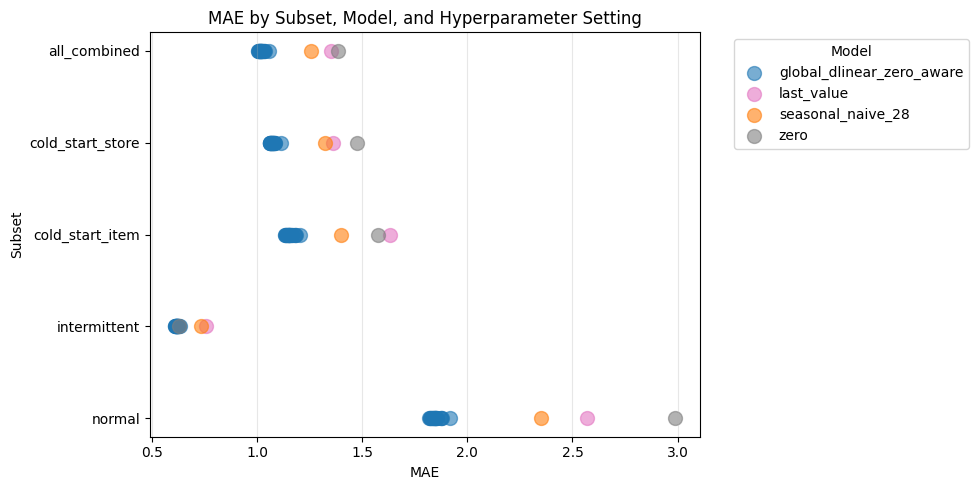

In [49]:
model_colors = {
    "zero": "tab:gray",
    "last_value": "tab:pink",
    "seasonal_naive_28": "tab:orange",
    MODEL_NAME: "tab:blue",
}

# Convert categorical subset labels to numeric y positions.
subset_to_y = {subset: i for i, subset in enumerate(subsets_order)}
scatter_df["subset_y"] = scatter_df["subset"].map(subset_to_y)

plt.figure(figsize=(10, 5))

for model_name, model_data in scatter_df.groupby("model"):
    plt.scatter(
        model_data["mae"],
        model_data["subset_y"],
        label=model_name,
        color=model_colors.get(model_name),
        alpha=0.6,
        s=100,
    )

plt.yticks(
    ticks=range(len(subsets_order)),
    labels=subsets_order,
)

plt.xlabel("MAE")
plt.ylabel("Subset")
plt.title("MAE by Subset, Model, and Hyperparameter Setting")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
output_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_zero_aware_v1_grid_results.csv"
)

output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)

output_path


WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/Results/dlinear_zero_aware_v1_grid_results.csv')

: 